In [ ]:
#============================================
#Import needed libraries
#============================================
import os
#print(os.getcwd())
os.chdir("/Users/ryankim/surfactant-ml")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

#Load dataset
df = pd.read_csv("data/processed_surfactants.csv")

#Target: pCMC
y = df["pCMC"]

#3 features will be comapred: descriptors only, fingerprints only, combined
#Determine which feature is the best

#==============================================
# 1. Descriptors Only
#==============================================
descriptors_col = [
    "MolWt", 
    "MolLogP", 
    "TPSA", 
    "NumHDonors", 
    "NumHAcceptors", 
    "RingCount", 
    "HeavyAtomCount",
    "RotatableBonds",
    "tail_length",
    "aromatic_flag",
    "ionic_encoded",
    "ethoxylate_count"
    ]

X_desc = df[descriptors_col]

#==============================================
# 2. Fingerprints Only
#==============================================
fp_cols = [
    col for col in df.columns
    if col.startswith("FP_")
]

X_fp = df[fp_cols]

#==============================================
# 3. Descriptor AND Fingerprints 
#==============================================
X_combined = pd.concat(
    [X_desc, X_fp],
    axis=1
)

#==============================================
# 4. Test Train Split 
#==============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size = 0.2,
    random_state = 42
)



# Model 1: Linear Regression
Create a linear regression with each factor such as:
 y = b_0 + b_1 * x_1 + b_2 * x_2 + ...

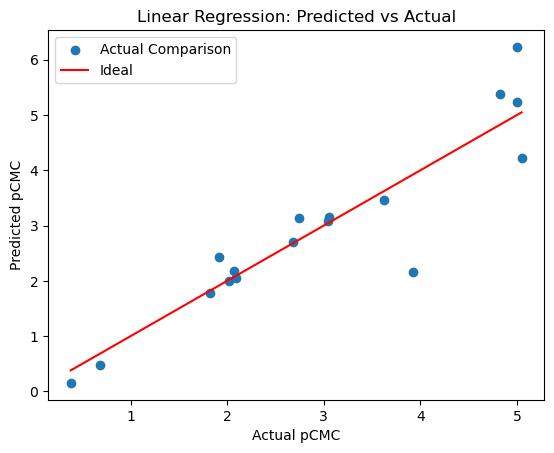

In [21]:
#==============================================
# Scale data so that there are equal contributions from each factor
#==============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#==============================================
# Model 1: Linear Regression
#==============================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

#Actual vs. Predicted
plt.scatter(y_test,y_pred_lr, label = 'Actual Comparison')
#y = x for ideal fit
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r-', label = 'Ideal')
# Labels
plt.xlabel("Actual pCMC")
plt.ylabel("Predicted pCMC")

# Title
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()

plt.show()



# Model 2: Random Forest
Train multiple decision treee then average predictions together
Decision trees are like flowcharts - if (condition), move right or left

.fit()
1) Each tree randomly samples training data and only sees a subset of features
2) Tree splitting
*Random forest is a nonlinear regression

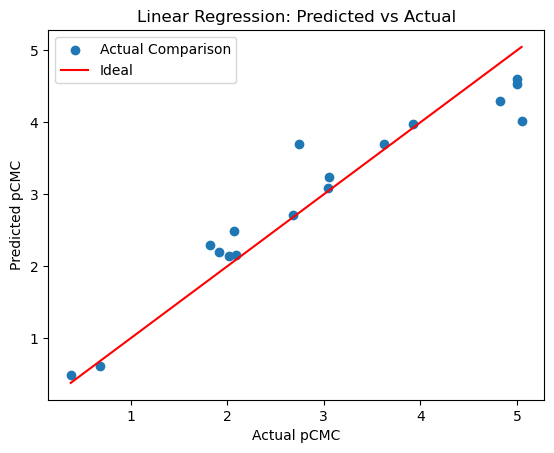

In [22]:
#==============================================
# Model 2: Random Forest
#==============================================
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#Actual vs. Predicted
plt.scatter(y_test,y_pred_rf, label = 'Actual Comparison')
#y = x for ideal fit
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r-', label = 'Ideal')
# Labels
plt.xlabel("Actual pCMC")
plt.ylabel("Predicted pCMC")

# Title
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()

plt.show()

# Model 3: XGBoost
Stands for "Extreme Gradient Boosting"
Uses decisions tress but unlike random forest, builds tree sequentially which each tree correcting previous mistake
Better nonlinear learning

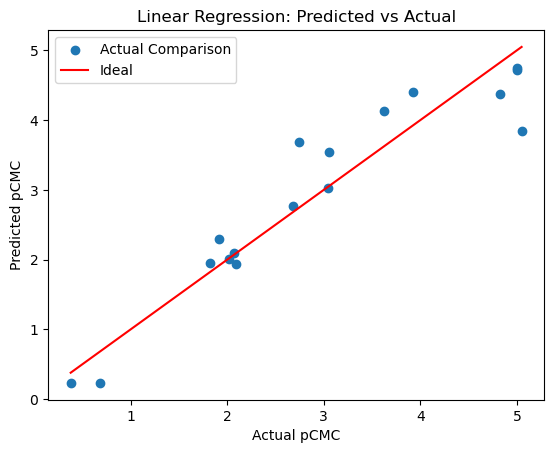

In [18]:
#==============================================
# Model 3: XGBoost
#==============================================
xgb_model = XGBRegressor(
    #Each tree = attempt to improve previous
    n_estimators=300, #300 trees
    learning_rate=0.05, #How aggressively each new tree updates prediction
    max_depth=6, #Complexity of each tree
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

#Actual vs. Predicted
plt.scatter(y_test,y_pred_xgb, label = 'Actual Comparison')
#y = x for ideal fit
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r-', label = 'Ideal')
# Labels
plt.xlabel("Actual pCMC")
plt.ylabel("Predicted pCMC")

# Title
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()

plt.show()

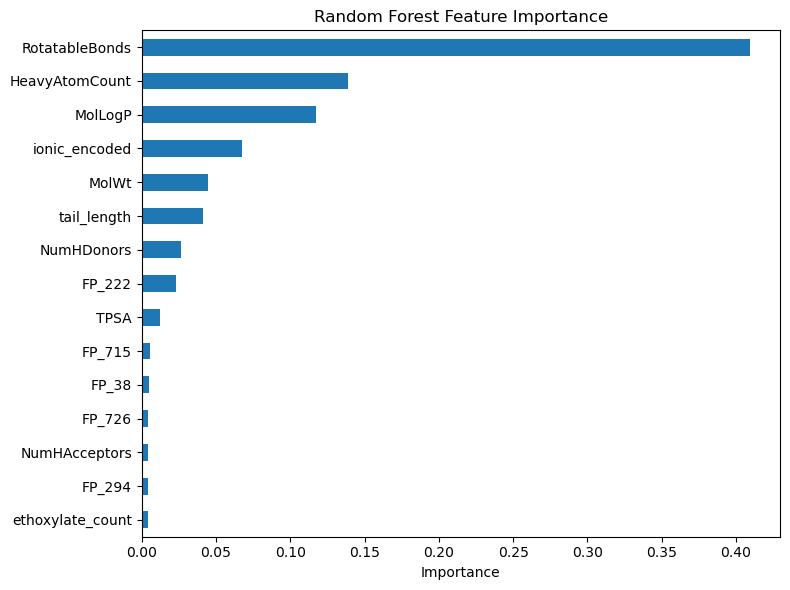

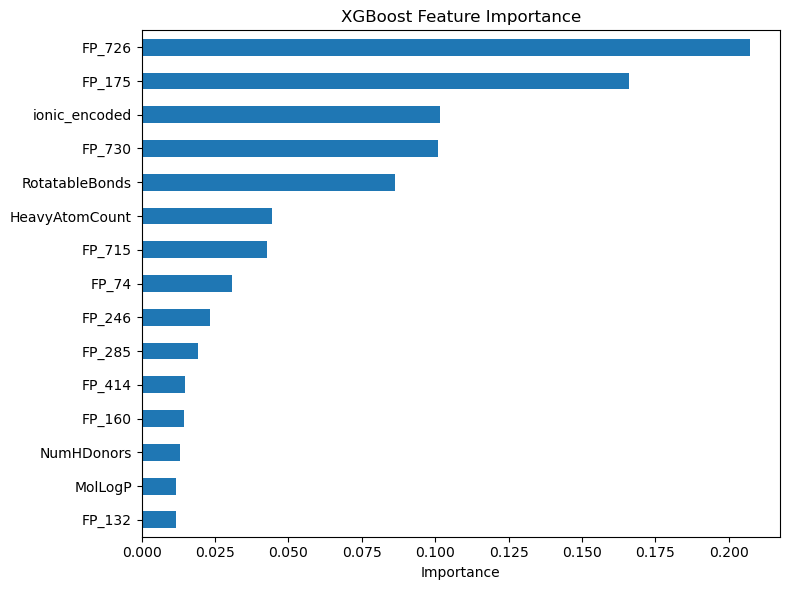

In [25]:
importance_rf = rf_model.feature_importances_

feat_imp_rf = pd.Series(
    importance_rf,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feat_imp_rf.head(15)

plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

importance_xgb = xgb_model.feature_importances_

feat_imp_xgb = pd.Series(
    importance_xgb,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feat_imp_xgb.head(15)

plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()